In [10]:
from src.data_loader import download_prices

from src.returns import (
    calculate_simple_returns,
    calculate_log_returns,
    validate_returns
)

from src.portfolio import (
    calculate_portfolio_returns,
    calculate_portfolio_pnl
)

In [ ]:
tickers = [
    "RELIANCE.NS",
    "ESCORTS.NS",
    "INFY.NS",
    "ABB.NS",
    "HDFCBANK.NS"
]

prices = download_prices(
    tickers,
    "2022-04-01",
    "2026-04-01"
)



print(prices.head().round(2))

[                       0%                       ]

[*********************100%***********************]  5 of 5 completed

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [13]:
returns = calculate_simple_returns(prices)

print(returns.head())

Ticker        ABB.NS  ESCORTS.NS  HDFCBANK.NS   INFY.NS  RELIANCE.NS
Date                                                                
2022-04-04  0.007688    0.039518     0.100119 -0.010821     0.002960
2022-04-05  0.036141    0.056230    -0.029295 -0.011605    -0.014132
2022-04-06  0.000862    0.013464    -0.035694 -0.017330    -0.002674
2022-04-07 -0.007830   -0.092170    -0.021981 -0.009757    -0.017636
2022-04-08  0.021348   -0.061246    -0.001395  0.001986     0.016631


In [14]:
print(validate_returns(returns))

{'rows': 986, 'columns': 5, 'missing_values': np.int64(0), 'infinite_values': np.int64(0)}


In [ ]:
#weightage of stocks in portfolio
weights = [
    0.20,   # RELIANCE
    0.20,   # ESCORTS
    0.20,   # INFY
    0.20,   # ABB
    0.20    # HDFCBANK
]

print(returns.columns)

Index(['ABB.NS', 'ESCORTS.NS', 'HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS'], dtype='str', name='Ticker')


In [45]:
portfolio_returns = calculate_portfolio_returns(
    returns,
    weights
)
print(prices.head().round(2))

#assigning portfolio value in Rs
portfolio_value = 10_000_000

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [38]:
#calculating daily PnL
portfolio_pnl = calculate_portfolio_pnl(
    portfolio_returns,
    portfolio_value
)

print(portfolio_pnl.head(10))

Date
2022-04-04    279000.0
2022-04-05     75000.0
2022-04-06    -83000.0
2022-04-07   -299000.0
2022-04-08    -45000.0
2022-04-11   -111000.0
2022-04-12   -156000.0
2022-04-13    -16000.0
2022-04-18   -280000.0
2022-04-19   -105000.0
Name: Portfolio P&L, dtype: float64


In [ ]:
#portfolio Stats
print("Portfolio Mean Return:")
print(portfolio_returns.mean())

print("\nPortfolio Volatility:")
print(portfolio_returns.std())

print("\nWorst Daily Return:")
print(portfolio_returns.min())

print("\nBest Daily Return:")
print(portfolio_returns.max())

Portfolio Mean Return:
0.0004188640973630832

Portfolio Volatility:
0.01015279057574383

Worst Daily Return:
-0.0569

Best Daily Return:
0.055


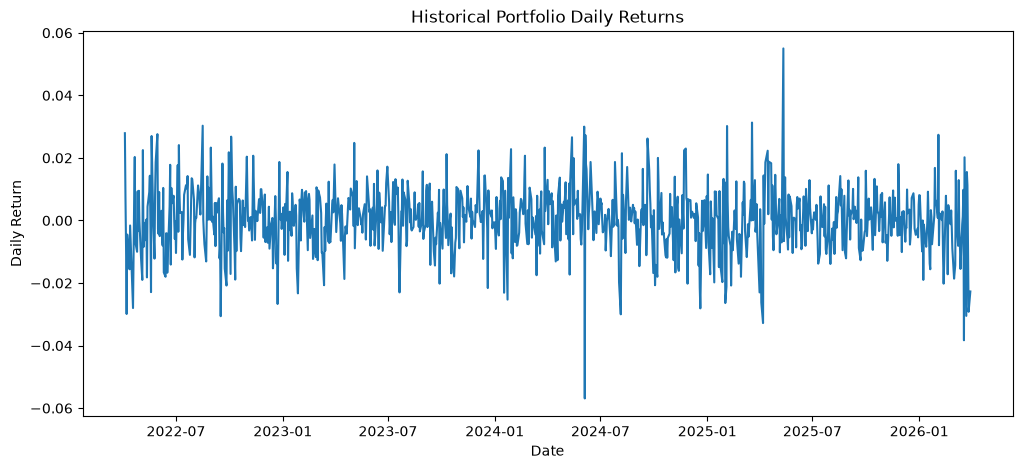

In [44]:
#Plotting Portfolio returns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_returns.index,
    portfolio_returns
)

plt.title("Historical Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

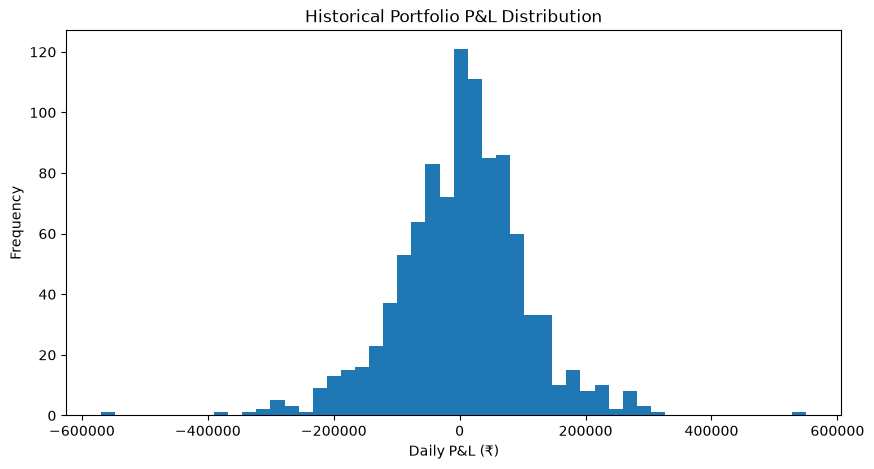

In [43]:
#Plotting PnL Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_pnl,
    bins=50
)

plt.title("Historical Portfolio P&L Distribution")
plt.xlabel("Daily P&L (₹)")
plt.ylabel("Frequency")

plt.show()